In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
cd drive/MyDrive/AI/인사교_LangChain_20260624

/content/drive/MyDrive/AI/인사교_LangChain_20260624


# 학습내용
- LangGraph 개요
- LangGraph에 자주 등장하는 Python 문법이해
- LangGraph를 활용한 챗봇 구축
- LangGraph를 활용한 Agent 구축
- Agent에 메모리 추가
- 노드의 단계별 스트리밍 출력
- Naive RAG
- 관련성 체커(Relevance Checker) 모듈 추가
- 웹 검색 모듈 추가
- 쿼리 재작성 모듈 추가

In [4]:
!pip install -qU langchain langchain-openai langchain-community langchain-experimental
!pip install -qU langchain-chroma faiss-cpu langchain-teddynote
!pip install -qU langchain-tavily google-search-results pypdf
!pip install -qU mypy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.4/120.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.7/42.7 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.3 MB/s eta 0:00:00
  Preparing meta

In [5]:
import os

In [6]:
# OpenAI Key 환경변수 설정
with open("/content/drive/MyDrive/AI/인사교_LangChain_20260624/key/openai_key.txt", "r") as f:
    api_key = f.read().strip()

os.environ['OPENAI_API_KEY'] = api_key

In [7]:
from uuid import uuid4

# 타입 설정
# Sequence : 메시지들의 순서 있는 시퀀스(리스트) 객체 (list 또는 tuple 형태로 메시지를 저장)
# Literal : 값 자체를 타입으로 제한할 수 있도록 해주는 기능
from typing import Annotated, TypedDict, Dict, List, Sequence, Literal
# pydantic : Python 데이터 검증과 설정 관리를 위한 라이브러리
from pydantic import Field, BaseModel, ValidationError

# 상태, 노드
# 노드 : 그래프에서의 작업 단위, 실제 작업을 수행하는 함수
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
# 도구를 노드로 만드는 기능 (자동 맵핑, 상태업데이트, 다중 실행)
from langgraph.prebuilt import ToolNode
# 도구 노드의 결과에 따라 자동으로 라우팅 경로를 설정
from langgraph.prebuilt import tools_condition

# 메모리 저장소
from langgraph.checkpoint.memory import MemorySaver

# 실행 설정
from langchain_core.runnables import RunnableConfig

# 시각화
from IPython.display import Image, display, Markdown
from langchain_teddynote.messages import stream_graph

# 모델 설정
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate, MessagesPlaceholder
# BaseMessage : BaseMessage를 상속한 다양한 메시지 타입 (HumanMessage, AIMessage, SystemMessage)
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage

# 웹 검색 도구
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_tavily import TavilySearch

# 도구 정의 데코레이터
from langchain.tools import tool

# RAG 라이브러리
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings

from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

/tmp/ipykernel_3264/1713186123.py:36: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


#LangGraph 개요
- 2024년 1월 출시
- LLM을 사용한 상태유지가 가능한 다중 액터 애플리케이션을 구축하기 위한 라이브러리
  - <font color="red">다중 에이전트 협업</font>: 각기 다른 도메인의 전문 에이전트들이 협력하여 복잡한 문제를 해결
  - <font color="red">도구 정의와 활용</font>: 특정 작업에 적합한 도구들을 정의하고, 이를 에이전트가 활용하는 방법을 설명
  - <font color="red">그래프 기반 시스템 구축</font>: 에이전트들이 서로 통신하고 협력하는 그래프를 생성


### 기존 workflow의 문제점
- 기존의 squential한 workflow 기반 RAG는 검색된 데이터의 유사도가 떨어지더라고 참고해서 답변하는 성향이 있다. -> 환각현상이 줄더라도 답변의 신뢰성이 약하다

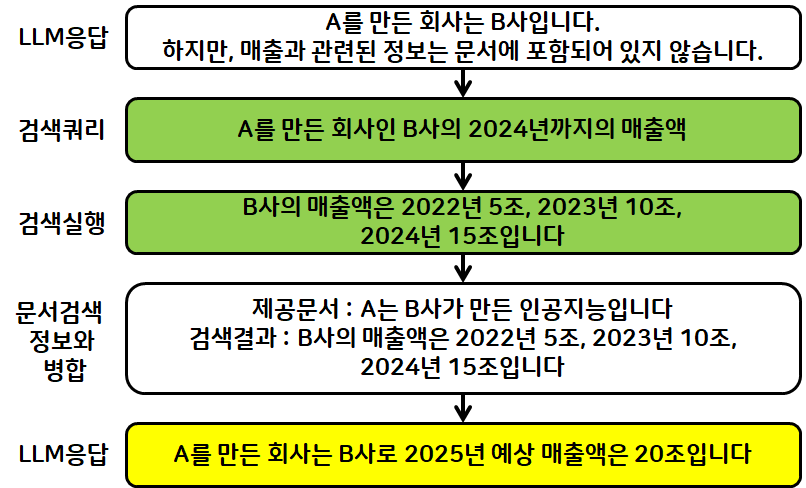



###해결방안:평가자 추가
- case 1

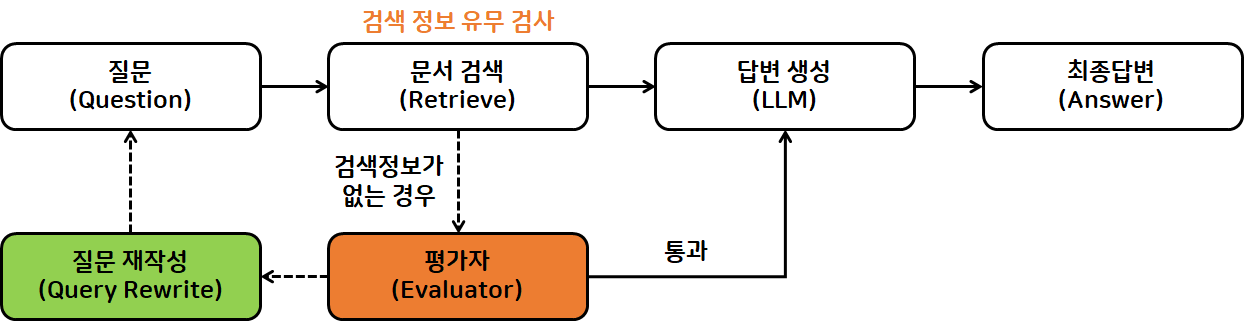

- case 2

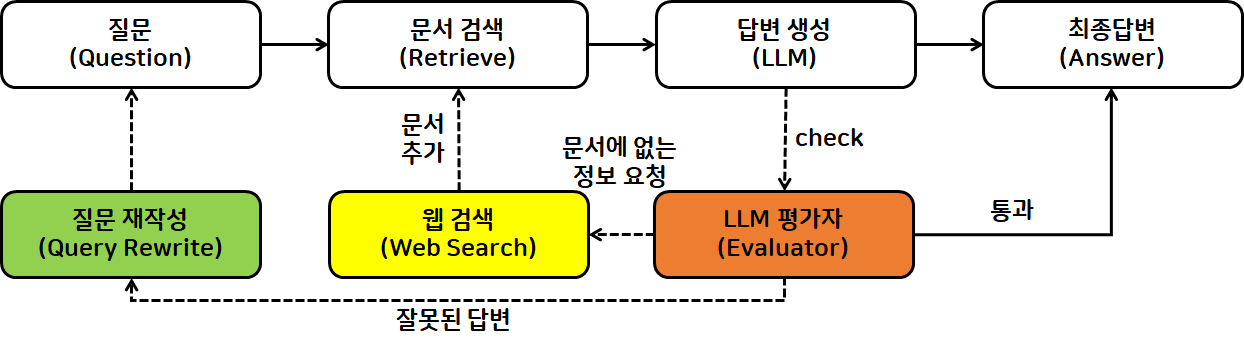

# LangGraph에 자주 등장하는 문법 이해

### TypedDict
  - dict와의 차이점
    - <font color="red">정적 타입 검사</font> 제공
    - 각 <font color="red">키</font>에 대해 <font color="red">구체적인 타입</font>을 지정해야 함
    - <font color="red">정의된 구조</font>에 따라 사용해야 함 (추가적인 키는 타입 오류 발생)

  - TypedDict를 사용하는 이유
    - 엄격한 타입 검사로 잠재적인 <font color="red">버그 방지</font>
    - 딕셔너리 구조를 명확하게 정의할 수 있어 <font color="red">코드 가독성 향상</font>
    - IDE에서 <font color="red">자동 완성 및 타입 힌트</font>를 더 정확하게 제공
    - 코드 자체가 문서의 역할을 하여 <font color="red">딕셔너리의 구조를 명확히</font> 보여줌     


In [8]:
%%writefile ./source/testDict.py
# 딕셔너리 생성
dict1 = {"name" : "홍길동", "age":24, "job" : "의적"}

# age를 문자열로 변경
dict1['age'] = "35"
# 새로운 key 추가
dict1['region'] = "장성"

Overwriting ./source/testDict.py


In [9]:
%%writefile ./source/testTypedDict.py
from typing import TypedDict

# 내가 지정한 타입만 들어가는 나만의 dict 생성
class Person(TypedDict):
    name : str
    age : int
    job : str

typed_dict1 : Person = {"name" : "홍길동", "age":24, "job" : "의적"}

# age를 문자열로 변경
typed_dict1['age'] = "35"
#새로운 key 추가
typed_dict1['region'] = "장성"

Overwriting ./source/testTypedDict.py


In [10]:
# 실행 후 결과비교
!python3 -m mypy ./source/testDict.py

Success: no issues found in 1 source file


In [11]:
!python3 -m mypy ./source/testTypedDict.py

source/testTypedDict.py:12: error: Value of "age" has incompatible type "str"; expected "int"  [typeddict-item]
source/testTypedDict.py:14: error: TypedDict "Person" has no key "region"  [typeddict-unknown-key]
Found 2 errors in 1 file (checked 1 source file)


### State(상태)
- 노드와 노드 간 정보를 전달할 때 활용
- TypedDict같은 타입체킹 구조를 활용
- 모든 값을 채우지 않아도 활용 가능
- 새로운 노드에서 값 덮어쓰기 방식으로 활용

In [12]:
# 기본 State 생성
class BasicState(TypedDict) :
  context : str
  question : str
  answer : str
  score : str
  relevance : str

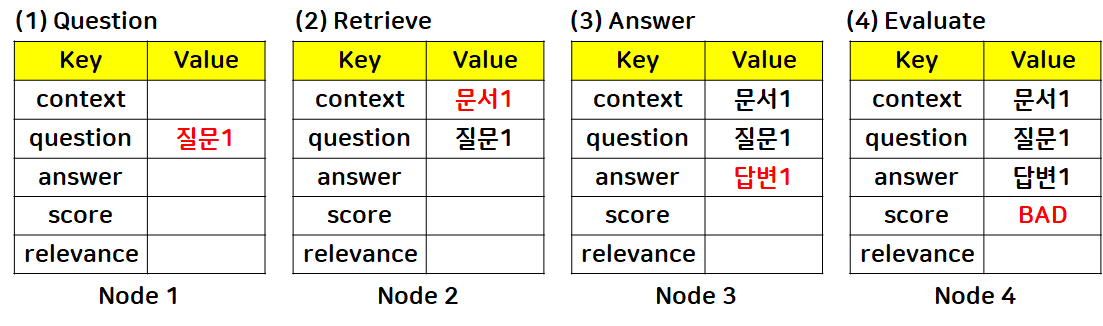

### Node
- 함수로 정의
- 입력인자는 State
- 반환 값도 대붑분 State
- Conditional Edge의 경우 다를 수 있음

In [13]:
# retriveNode 정의
def retrive_Node(s : BasicState) -> BasicState :
  # 사용자 query에 맞는 chunck를 탐색했다고 가정하고 구성
  s['context'] = "광주는 현재 오도가 24도 입니다. 날씨가 화창하고 좋습니다."
  return s


In [14]:
# llm_answer_Node 정의
def llm_answer_Node(s : BasicState) -> BasicState :
  # LLM이 답변을 생성했다고 가정하고 구성
  llm_answer = "답변1"

  return BasicState(answer=llm_answer)

In [15]:
# relevance_check_node 정의
def relevance_check_node(s : BasicState) -> BasicState :
  # retreiver로 검색된 데이터와 LLM이 생성한 답변의 일치도르를 검사한다고 가정
  s['relevance'] = 'grounded' # 검색 문서기반으로 답변이 생성되었다고 표현하는 값 업데이트
  return s

In [16]:
# 노드 등록하기
graph_builder = StateGraph(BasicState) # 그래프의 베이스 생성

graph_builder.add_node("retrive_Node", retrive_Node) # 노드이름, 수행가능한 노드 함수
graph_builder.add_node("llm_answer_Node", llm_answer_Node)
graph_builder.add_node("relevance_check_node", relevance_check_node)

### Edge
- 노드와 노드 사이를 연결

In [17]:
graph_builder.add_edge("retrive_Node", "llm_answer_Node") # 시작노드, 끝 노드
graph_builder.add_edge("llm_answer_Node", "relevance_check_node")

### Conditional Edge (조건부 엣지)
- 노드에 조건부 엣지를 추가해 분기를 수행

In [18]:
def is_relevant(s : BasicState) -> Literal['grounded', 'notGrounded', "notSure"] :
  return s['relevance']

In [19]:
graph_builder.add_conditional_edges(
    source = "relevance_check_node", # 조건부 엣지를 붙일 노드이름
    path = is_relevant, # 조건분기를 판별하는 함수
    path_map = { # 분기될 노드지정
                'grounded' : END, # 문서기반 답변인 경우 끝낸다
                 'notGrounded' : 'llm_answer_Node', # 문서기반 답변이 아니면 LLM으로 보내 재생성
                 'notSure' : 'retrive_Node' #  모호한 경우 문서검색부터 다시
    }
)

### 그래프 생성 및 시각화
- 그래프 시작점 지정
- compile
- 시각화

In [20]:
# 시작점 지정
graph_builder.set_entry_point('retrive_Node')

In [21]:
# 그래프 컴파일
graph = graph_builder.compile()


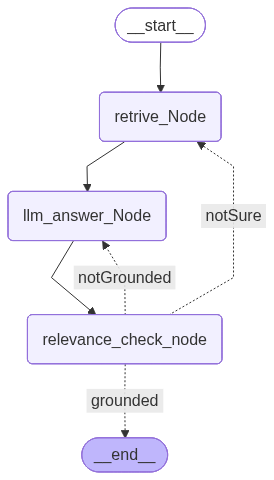

In [22]:
# 그래프 시각화
display(Image(graph.get_graph().draw_mermaid_png()))

# LangGraph 챗봇 구성하기
- 1. 상태정의
- 2. 노드정의
- 3. 그래프 생성 및 노드 추가
- 4. 엣지 추가(컨디셔널 엣지 포함)
- 5. 그래프 컴파일
- 6. 그래프 시각화
- 7. 그래프 실행

# 1.상태정의

In [23]:
class ChatbotState(TypedDict) :
  messages : Annotated[list, "사용자의 메세지를 담는 리스트"]

#2.노드정의

In [24]:
# LLM 생성
llm = init_chat_model(model="openai:gpt-4o-mini", max_tokens=500)

In [25]:
def chatbot(s : ChatbotState) :
  # 메세지 호출 및 반환
  response = llm.invoke(s['messages'])
  return ChatbotState(messages=[response])

#3.그래프 생성 및 노드 추가

In [26]:
chatbot_graph_builder = StateGraph(ChatbotState)

chatbot_graph_builder.add_node("chatbot", chatbot)

#4.엣지 추가

In [27]:
chatbot_graph_builder.set_entry_point("chatbot")
chatbot_graph_builder.add_edge("chatbot", END)

#5.그래프 컴파일

In [29]:
chatbot_graph = chatbot_graph_builder.compile()

#6.그래프 시각화

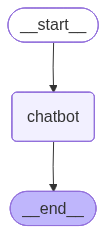

In [31]:
# 그래프 시각화
display(Image(chatbot_graph.get_graph().draw_mermaid_png()))

#7.그래프 실행

In [33]:
question = "광주의 유명한 맛집 Top3 추천해줘"
response = chatbot_graph.invoke({"messages" : [('user', question)]})

In [34]:
response

{'messages': [AIMessage(content='광주에는 맛있는 음식점이 많아서 선택하기 어렵지만, 다음의 세 곳을 추천해 드립니다.\n\n1. **광주식당 (Gwangju Sikdang)** - 전통적인 한국식 찌개와 밥을 제공하는 곳으로, 특히 김치찌개가 유명합니다. 신선한 재료와 해장국 맛이 일품입니다.\n\n2. **조선족부대찌개 (Joseonjok Budaejjigae)** - 매콤한 부대찌개를 전문으로 하는 식당으로, 여러 가지 재료가 들어가 풍미가 깊습니다. 특히 친구나 가족과 함께 방문할 때 좋습니다.\n\n3. **전주비빔밥 (Jeonju Bibimbap)** - 광주에 위치한 전주비빔밥 전문점으로, 다양한 나물과 고기, 고소한 계란이 어우러진 비빔밥을 제공하여 건강하면서도 맛있는 한 끼를 즐기기에 좋습니다.\n\n각 장소의 운영 시간이나 메뉴는 사전에 확인하는 것이 좋습니다. 광주에서 맛있는 식사를 즐기시길 바랍니다!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 248, 'prompt_tokens': 18, 'total_tokens': 266, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_88876bec1e', 'id': 'chatcmpl-Dx5NNyJY3tpwp3vfHe7LgOidVTzeH', 'service_tier': '